In [1]:
import os
import json
import torch
import matplotlib.pyplot as plt
from posixpath import join
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch_geometric.loader import DataLoader

from EGAT import EGAT_model
import StrokeGraphDataset_class


RUN_DIRECTORY = "./checkpoints/40.0,2.0,23,19,2(5)/run_20260328_201146" 

BATCHES_DIRECTORY = "./batches/" + RUN_DIRECTORY["./checkpoints/".__len__():RUN_DIRECTORY.find("run_")-1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cuda


In [2]:
def read_config(path: str):
    with open(path, 'r') as f:
        return json.load(f)

configs = read_config(join(RUN_DIRECTORY, 'config.json'))
file_lists = read_config(join(RUN_DIRECTORY, 'file_list.json'))

test_files = file_lists.get("file test list:", [])
test_files_with_aug = list(test_files)
test_aug_only_files = []

for f in test_files:
    base = f.replace('_proc.pt', '')
    test_aug_only_files.extend([
        af for af in os.listdir(BATCHES_DIRECTORY) 
        if (af.startswith('aug') or af.startswith('sep')) 
        and af.endswith('_proc.pt') 
        and base in af
    ])

test_files_with_aug.extend(test_aug_only_files)

if configs["out_channels"] == 2:
    class_names = ["Non-Text", "Text"]
elif configs["out_channels"] == 5:
    class_names = ["Text", "Table", "Formula", "Diagram", "Other"]
else:
    class_names = [f"Class {i}" for i in range(configs["out_channels"])]

print(f"Кількість оригінальних тестових файлів: {len(test_files)}")
print(f"Кількість файлів з аугментацією (оригінали + ауг): {len(test_files_with_aug)}")

Кількість оригінальних тестових файлів: 95
Кількість файлів з аугментацією (оригінали + ауг): 769


In [3]:
batch_size = configs.get("batch_size", 4)

temp_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files[:1])
temp_loader = DataLoader(temp_dataset, batch_size=1, shuffle=False)
sample_batch = next(iter(temp_loader))

model = EGAT_model(
    in_channels=sample_batch.x.size(1),
    hidden_channels=configs["hidden_channels"],
    out_channels=configs["out_channels"],
    edge_dim=sample_batch.edge_attr.size(1),
    heads=configs["heads"],
    num_hidden_layers=configs["hidden_layers"],
    dropout=configs["dropout"]
).to(device)

model_path = join(RUN_DIRECTORY, 'final_model.pt')
model.load_model(model_path, device)
model.eval()

print("Модель успішно завантажена та переведена в режим оцінки (eval)!")

Модель успішно завантажена та переведена в режим оцінки (eval)!


In [4]:
import torch.nn.functional as F
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    matthews_corrcoef, hamming_loss, jaccard_score, log_loss, roc_auc_score
)

def evaluate_and_plot(model, dataloader, device, class_names, title_prefix="Test"):
    """Проганяє дані через модель, виводить розширений звіт метрик і малює Confusion Matrix inline."""
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr)
            
            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*60}")
    print(f"--- РОЗШИРЕНІ МЕТРИКИ: {title_prefix.upper()} ---")
    print(f"{'='*60}")

    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    print("1. Звіт класифікації (Classification Report):\n", report)

    print("2. Додаткові метрики якості:")
    print(f"   - Accuracy (Загальна точність):          {accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Balanced Accuracy (Збалансована):      {balanced_accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Cohen's Kappa (Узгодженість):          {cohen_kappa_score(all_labels, all_preds):.4f}")
    print(f"   - Matthews Corrcoef (MCC)*:              {matthews_corrcoef(all_labels, all_preds):.4f}")
    print(f"   - Jaccard Score (Macro):                 {jaccard_score(all_labels, all_preds, average='macro'):.4f}")
    print(f"   - Hamming Loss (Частка помилок):         {hamming_loss(all_labels, all_preds):.4f}")
    
    print("\n3. Метрики на основі ймовірностей (Probabilities):")
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        print(f"   - ROC AUC (Macro OVR):                   {auc:.4f}")
    except Exception as e:
        print(f"   - ROC AUC: Неможливо обчислити ({e})")
        
    try:
        ll = log_loss(all_labels, all_probs)
        print(f"   - Log Loss (Крос-ентропія):              {ll:.4f}")
    except Exception as e:
        print(f"   - Log Loss: Неможливо обчислити ({e})")

    print("\n4. Confusion Matrix (Матриця помилок):")
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
    
    plt.title(f'Confusion Matrix ({title_prefix})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    #* MCC (Matthews Correlation Coefficient) вважається найкращою метрикою для незбалансованих класів (від -1 до +1).

=== Запуск тестування на оригінальних файлах ===

--- РОЗШИРЕНІ МЕТРИКИ: ORIGINAL FILES ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

        Text     0.9760    0.9857    0.9808     26932
       Table     0.7692    0.7192    0.7434       292
     Formula     0.8904    0.8404    0.8647      1585
     Diagram     0.8826    0.9042    0.8933      4698
       Other     0.7403    0.5677    0.6426      1175

    accuracy                         0.9516     34682
   macro avg     0.8517    0.8034    0.8249     34682
weighted avg     0.9497    0.9516    0.9502     34682

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.9516
   - Balanced Accuracy (Збалансована):      0.8034
   - Cohen's Kappa (Узгодженість):          0.8689
   - Matthews Corrcoef (MCC)*:              0.8692
   - Jaccard Score (Macro):                 0.7192
   - Hamming Loss (Частка помилок):         0.0484

3. Метрики на основі ймовірностей (P

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


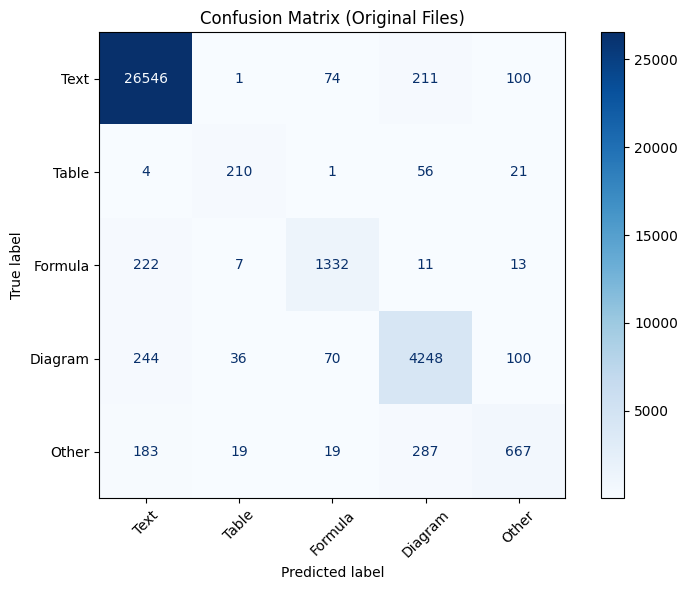

In [5]:
print("=== Запуск тестування на оригінальних файлах ===")
test_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

evaluate_and_plot(model, test_loader, device, class_names, title_prefix="Original Files")

=== Запуск тестування на файлах з аугментацією ===

--- РОЗШИРЕНІ МЕТРИКИ: WITH AUGMENTATION ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

        Text     0.9578    0.9807    0.9691    102280
       Table     0.7870    0.7332    0.7592      1668
     Formula     0.9020    0.8412    0.8705      5408
     Diagram     0.8451    0.9075    0.8752     23767
       Other     0.6544    0.3354    0.4435      7614

    accuracy                         0.9251    140737
   macro avg     0.8293    0.7596    0.7835    140737
weighted avg     0.9182    0.9251    0.9185    140737

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.9251
   - Balanced Accuracy (Збалансована):      0.7596
   - Cohen's Kappa (Узгодженість):          0.8240
   - Matthews Corrcoef (MCC)*:              0.8256
   - Jaccard Score (Macro):                 0.6771
   - Hamming Loss (Частка помилок):         0.0749

3. Метрики на основі ймовірност

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


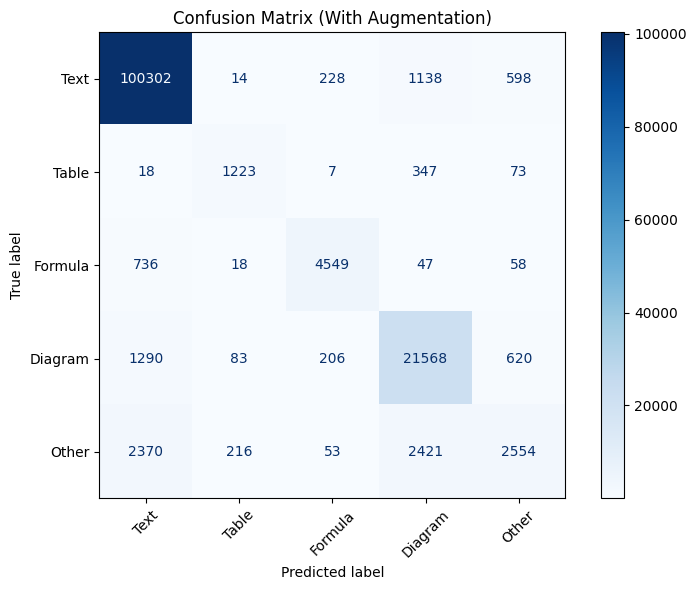

In [6]:
if test_aug_only_files:
    print("=== Запуск тестування на файлах з аугментацією ===")
    test_aug_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files_with_aug)
    test_aug_loader = DataLoader(test_aug_dataset, batch_size=batch_size, shuffle=False)

    evaluate_and_plot(model, test_aug_loader, device, class_names, title_prefix="With Augmentation")
else:
    print("Аугментовані файли не знайдені у директорії батчів. Цей крок пропущено.")
    